# Loading the Data

In [2]:
# Replace with the correct path for your dataset
!kaggle datasets download -d olistbr/brazilian-ecommerce

# If the file is a zip, unzip it
!unzip brazilian-ecommerce.zip

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 223MB/s] 

Archive:  brazilian-ecommerce.zip
  inflating: olist_customers_dataset.csv  
  inflating: olist_geolocation_dataset.csv  
  inflating: olist_order_items_dataset.csv  
  inflating: olist_order_payments_dataset.csv  
  inflating: olist_order_reviews_dataset.csv  
  inflating: olist_orders_dataset.csv  
  inflating: olist_products_dataset.csv  
  inflating: olist_sellers_dataset.csv  
  inflating: product_category_name_translation.csv  


In [3]:
import pandas as pd
import numpy as np

### Helper Functions

In [4]:
def value_counts_for_categorical_columns(df, drop_cols):
    categorical_columns = df.select_dtypes(include=['object']).columns
    categorical_columns = categorical_columns.drop(drop_cols)

    for col in categorical_columns:
        print(f"\n{'='*60}")
        print(f"COLUMN: {col.upper()}")
        print(f"{'='*60}")

        # Basic stats
        total = len(df[col])
        unique = df[col].nunique()
        missing = df[col].isnull().sum()
        print(f"Total Records: {total:,}")
        print(f"Unique Values: {unique:,}")
        print(f"Missing Values: {missing:,} ({missing/total*100:.2f}%)")
        print(f"\n{'='*60}")

        # Value counts with percentages
        counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100

        # Create combined DataFrame for better display
        summary = pd.DataFrame({
            'Count': counts,
            'Percentage': percentages
        })
        summary['Cumulative %'] = summary['Percentage'].cumsum()

        print(summary.to_string())
        print(f"\n{'='*60}\n")

In [5]:
def remove_white_spaces(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].str.strip()

In [6]:
def padding_zip_codes(df, cols):
    for col in cols:
        df[col] = df[col].astype(str).str.zfill(5)

In [7]:
def export_df_to_parquet(df, file_path):
    df.to_parquet(file_path, index=False, engine='pyarrow')

In [27]:
import matplotlib.pyplot as plt

In [28]:
def plot_value_counts(df, col):
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar', figsize=(10, 6))
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Value Counts for {col}')
    plt.xticks(rotation=45)
    plt.show()

In [12]:
DATA_PATH = "."

Loading the customers dataset

In [13]:
try:
    customers = pd.read_csv(f"{DATA_PATH}/olist_customers_dataset.csv")
    customers.head()
except Exception as e:
  print(f"Error loading the dataset: {e}")

Summary

print shape, dtypes, null counts, and value_counts() for categorical columns including order_status

In [14]:
customers.shape

(99441, 5)

In [48]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [16]:
customers.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [17]:
null_counts = customers.isnull().sum().reset_index()
null_counts.columns = ['Column', 'Null Count']
print(null_counts)

                     Column  Null Count
0               customer_id           0
1        customer_unique_id           0
2  customer_zip_code_prefix           0
3             customer_city           0
4            customer_state           0


In [18]:
value_counts_for_categorical_columns(customers,['customer_id','customer_unique_id'])


COLUMN: CUSTOMER_CITY
Total Records: 99,441
Unique Values: 4,119
Missing Values: 0 (0.00%)

                                  Count  Percentage  Cumulative %
customer_city                                                    
sao paulo                         15540   15.627357     15.627357
rio de janeiro                     6882    6.920687     22.548044
belo horizonte                     2773    2.788588     25.336632
brasilia                           2131    2.142979     27.479611
curitiba                           1521    1.529550     29.009161
campinas                           1444    1.452117     30.461279
porto alegre                       1379    1.386752     31.848030
salvador                           1245    1.251999     33.100029
guarulhos                          1189    1.195684     34.295713
sao bernardo do campo               938    0.943273     35.238986
niteroi                             849    0.853773     36.092759
santo andre                         797    0.8014

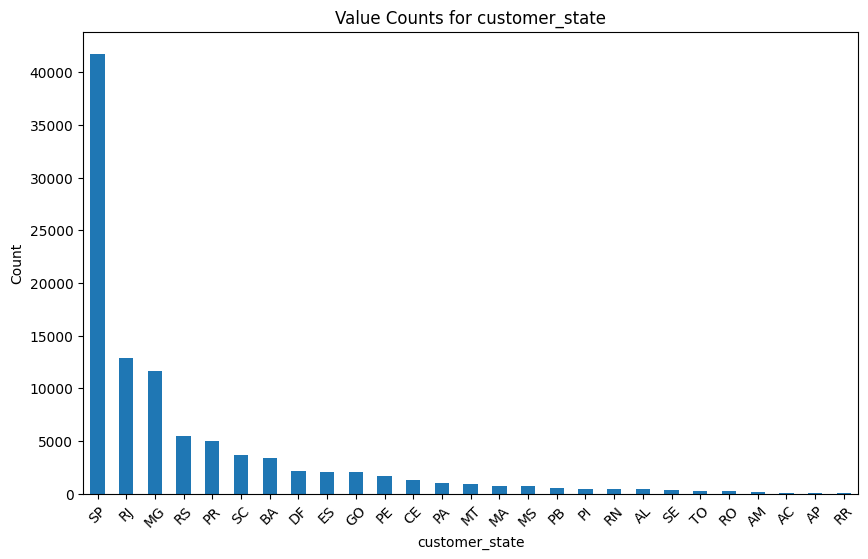

In [30]:
plot_value_counts(customers,'customer_state')

## Cleaning the dataset

In [19]:
print(customers.duplicated().sum())

0


no duplicate rows were found

In [23]:
assert customers.duplicated().sum() == 0

In [25]:
padding_zip_codes(customers,['customer_zip_code_prefix'])

In [26]:
assert customers.customer_zip_code_prefix.str.len().eq(5).all()

In [51]:
remove_white_spaces(customers)

In [124]:
export_df_to_parquet(customers,'customers.parquet')

## Loading Geolocation Dataset

In [33]:
try:
    geolocation=pd.read_csv(f"{DATA_PATH}/olist_geolocation_dataset.csv")
except Exception as e:
  print(f"Error loading the dataset: {e}")

In [34]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [35]:
geolocation.shape

(1000163, 5)

In [36]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [37]:
geolocation.describe(include="all")

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [55]:
geolocation.geolocation_state.nunique()

27

In [56]:
geolocation.geolocation_city.nunique()

8011

In [57]:
geolocation.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [58]:
value_counts_for_categorical_columns(geolocation,['geolocation_city'])


COLUMN: GEOLOCATION_STATE
Total Records: 1,000,163
Unique Values: 27
Missing Values: 0 (0.00%)

                    Count  Percentage  Cumulative %
geolocation_state                                  
SP                 404268   40.420212     40.420212
MG                 126336   12.631541     53.051753
RJ                 121169   12.114925     65.166678
RS                  61851    6.184092     71.350770
PR                  57859    5.784957     77.135727
SC                  38328    3.832175     80.967902
BA                  36045    3.603913     84.571815
GO                  20139    2.013572     86.585387
ES                  16748    1.674527     88.259914
PE                  16432    1.642932     89.902846
DF                  12986    1.298388     91.201234
MT                  12031    1.202904     92.404138
CE                  11674    1.167210     93.571348
PA                  10853    1.085123     94.656471
MS                  10431    1.042930     95.699401
MA                 

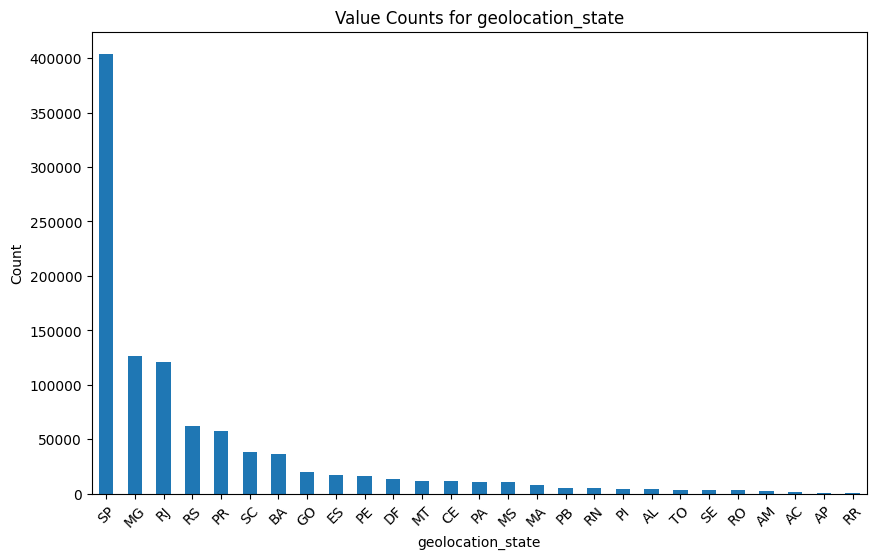

In [38]:
plot_value_counts(geolocation,'geolocation_state')

Cleaning the dataset

In [59]:
geolocation[geolocation.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [60]:
print(geolocation.duplicated().sum())

261831


261831 duplicate rows were found so we need to drop the duplicates

In [39]:
geolocation.drop_duplicates(inplace=True)

In [40]:
print(geolocation.duplicated().sum())

0


In [41]:
assert geolocation.duplicated().sum() == 0

## Removing white spaces

In [44]:
remove_white_spaces(geolocation)

In [45]:
padding_zip_codes(geolocation,['geolocation_zip_code_prefix'])

In [46]:
assert geolocation.geolocation_zip_code_prefix.str.len().eq(5).all()

In [47]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,01037,-23.545621,-46.639292,sao paulo,SP
1,01046,-23.546081,-46.644820,sao paulo,SP
2,01046,-23.546129,-46.642951,sao paulo,SP
3,01041,-23.544392,-46.639499,sao paulo,SP
4,01035,-23.541578,-46.641607,sao paulo,SP


exporting the cleaned dataset to a parquet file

In [48]:
export_df_to_parquet(geolocation,'geolocation.parquet')

## loading order items data

In [49]:
try:
    order_items=pd.read_csv(f"{DATA_PATH}/olist_order_items_dataset.csv",parse_dates=['shipping_limit_date'])
except Exception as e:
  print(f"Error loading the dataset: {e}")


In [50]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [51]:
order_items.shape

(112650, 7)

In [52]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [54]:
order_items.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


In [56]:
order_items.describe(include="object")

,order_id,product_id,seller_id
count,112650,112650,112650
unique,98666,32951,3095
top,8272b63d03f5f79c56e9e4120aec44ef,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0
freq,21,527,2033


In [57]:
order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


cleaning the dataset

In [58]:
print(order_items.duplicated().sum())

0


no duplicates were found

In [59]:
export_df_to_parquet(order_items,'order_items.parquet')

## Loading order payments data

In [60]:
try:
    order_payments=pd.read_csv(f"{DATA_PATH}/olist_order_payments_dataset.csv")
except Exception as e:
  print(f"Error loading the dataset: {e}")


In [61]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [62]:
order_payments.shape

(103886, 5)

In [63]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [65]:
value_counts_for_categorical_columns(order_payments,['order_id'])


COLUMN: PAYMENT_TYPE
Total Records: 103,886
Unique Values: 5
Missing Values: 0 (0.00%)

              Count  Percentage  Cumulative %
payment_type                                 
credit_card   76795   73.922376     73.922376
boleto        19784   19.043952     92.966328
voucher        5775    5.558978     98.525307
debit_card     1529    1.471806     99.997112
not_defined       3    0.002888    100.000000




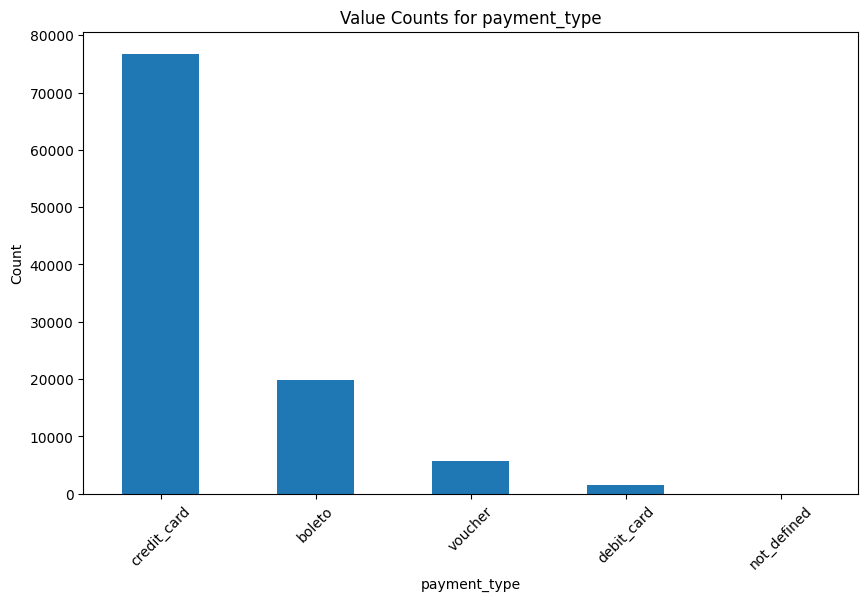

In [64]:
plot_value_counts(order_payments,'payment_type')

## Cleaning the Data

In [66]:
print(order_payments.duplicated().sum())

0


In [67]:
assert order_payments.duplicated().sum() == 0

no duplicate rows were found

In [68]:
remove_white_spaces(order_payments)

In [69]:
export_df_to_parquet(order_payments,'order_payments.parquet')

## Loading order_reviews

In [70]:
try:
    order_reviews=pd.read_csv(f"{DATA_PATH}/olist_order_reviews_dataset.csv",parse_dates=['review_creation_date','review_answer_timestamp'])
except Exception as e:
  print(f"Error loading the dataset: {e}")


In [71]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [72]:
order_reviews.describe()

,review_score,review_creation_date,review_answer_timestamp
count,99224.000000,99224,99224
mean,4.086421,2018-01-12 20:49:23.948238336,2018-01-16 00:23:56.977938688
min,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,4.000000,2017-09-23 00:00:00,2017-09-27 01:53:27.249999872
50%,5.000000,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,5.000000,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,1.347579,NaN,NaN


In [73]:
order_reviews.describe(include="object")

,review_id,order_id,review_comment_title,review_comment_message
count,99224,99224,11568,40977
unique,98410,98673,4527,36159
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,Recomendo,Muito bom
freq,3,3,423,230


In [74]:
order_reviews.shape

(99224, 7)

In [75]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [76]:
order_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [77]:
order_reviews.review_score.value_counts()

,count
review_score,
5,57328
4,19142
1,11424
3,8179
2,3151


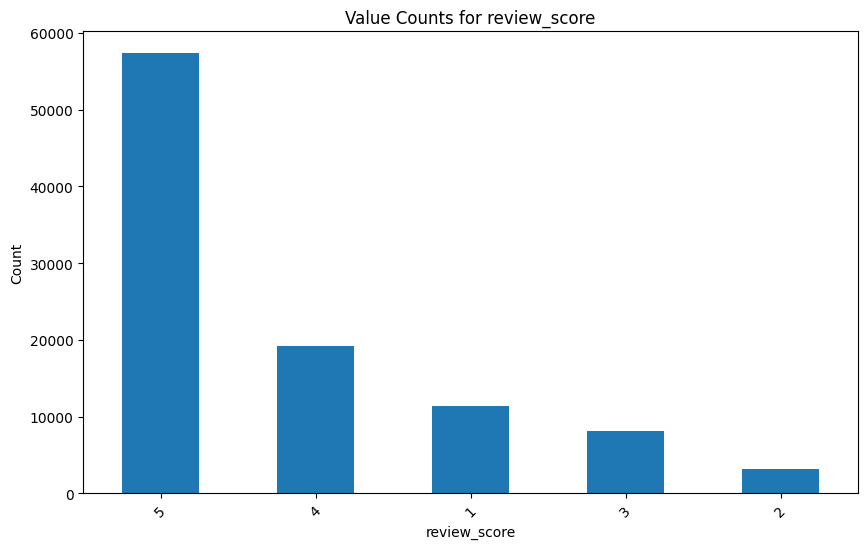

In [78]:
plot_value_counts(order_reviews,'review_score')

cleaning the data

In [79]:
order_reviews.duplicated().sum()

np.int64(0)

no duplicate rows were found

In [80]:
remove_white_spaces(order_reviews)

In [81]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [82]:
export_df_to_parquet(order_reviews,'order_reviews.parquet')

## loading orders dataset

In [83]:
try:
    orders=pd.read_csv(f"{DATA_PATH}/olist_orders_dataset.csv",parse_dates=['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date'])
except Exception as e:
  print(f"Error loading the dataset: {e}")


In [84]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [85]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [87]:
orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [86]:
orders.describe(include="object")

,order_id,customer_id,order_status
count,99441,99441,99441
unique,99441,99441,8
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered
freq,1,1,96478


In [88]:
orders.shape

(99441, 8)

In [89]:
value_counts_for_categorical_columns(orders,['order_id','customer_id'])


COLUMN: ORDER_STATUS
Total Records: 99,441
Unique Values: 8
Missing Values: 0 (0.00%)

              Count  Percentage  Cumulative %
order_status                                 
delivered     96478   97.020344     97.020344
shipped        1107    1.113223     98.133567
canceled        625    0.628513     98.762080
unavailable     609    0.612423     99.374503
invoiced        314    0.315765     99.690269
processing      301    0.302692     99.992961
created           5    0.005028     99.997989
approved          2    0.002011    100.000000




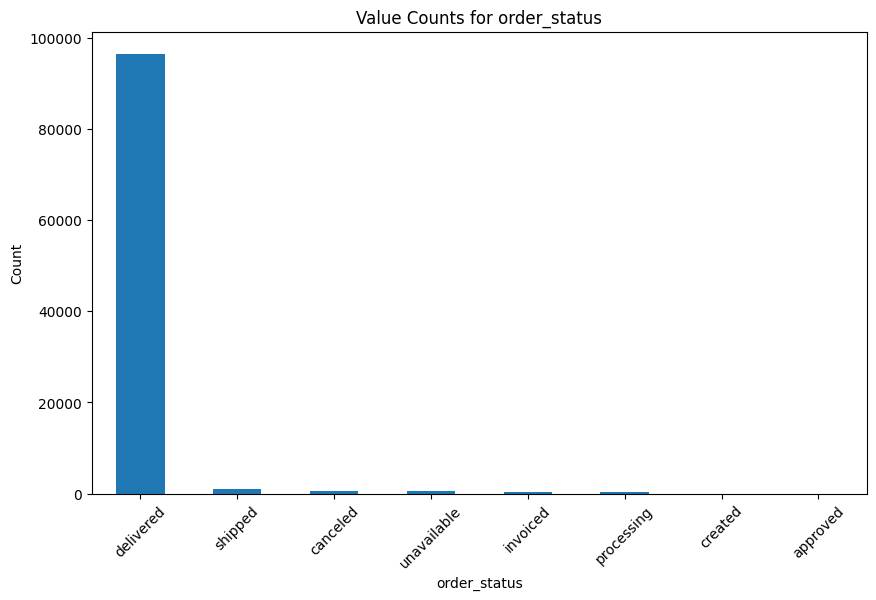

In [90]:
plot_value_counts(orders,'order_status')

## Cleaning the dataset

In [91]:
orders.duplicated().sum()

np.int64(0)

no duplicate rows were found

In [94]:
assert orders.duplicated().sum() == 0

In [92]:
remove_white_spaces(orders)

In [93]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [95]:
export_df_to_parquet(orders,'orders.parquet')

## Loading Products Dataset

In [97]:
try:
    products=pd.read_csv(f"{DATA_PATH}/olist_products_dataset.csv")
except Exception as e:
  print(f"Error loading the dataset: {e}")

In [98]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [99]:
products.shape

(32951, 9)

In [100]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [101]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [102]:
products.describe(include="object")

,product_id,product_category_name
count,32951,32341
unique,32951,73
top,106392145fca363410d287a815be6de4,cama_mesa_banho
freq,1,3029


In [103]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [104]:
products.product_category_name.fillna('unknown',inplace=True)

In [105]:
value_counts_for_categorical_columns(products,['product_id'])


COLUMN: PRODUCT_CATEGORY_NAME
Total Records: 32,951
Unique Values: 74
Missing Values: 0 (0.00%)

                                                Count  Percentage  Cumulative %
product_category_name                                                          
cama_mesa_banho                                  3029    9.192437      9.192437
esporte_lazer                                    2867    8.700798     17.893235
moveis_decoracao                                 2657    8.063488     25.956724
beleza_saude                                     2444    7.417074     33.373797
utilidades_domesticas                            2335    7.086280     40.460077
automotivo                                       1900    5.766138     46.226215
informatica_acessorios                           1639    4.974052     51.200267
brinquedos                                       1411    4.282116     55.482383
relogios_presentes                               1329    4.033262     59.515644
telefonia             

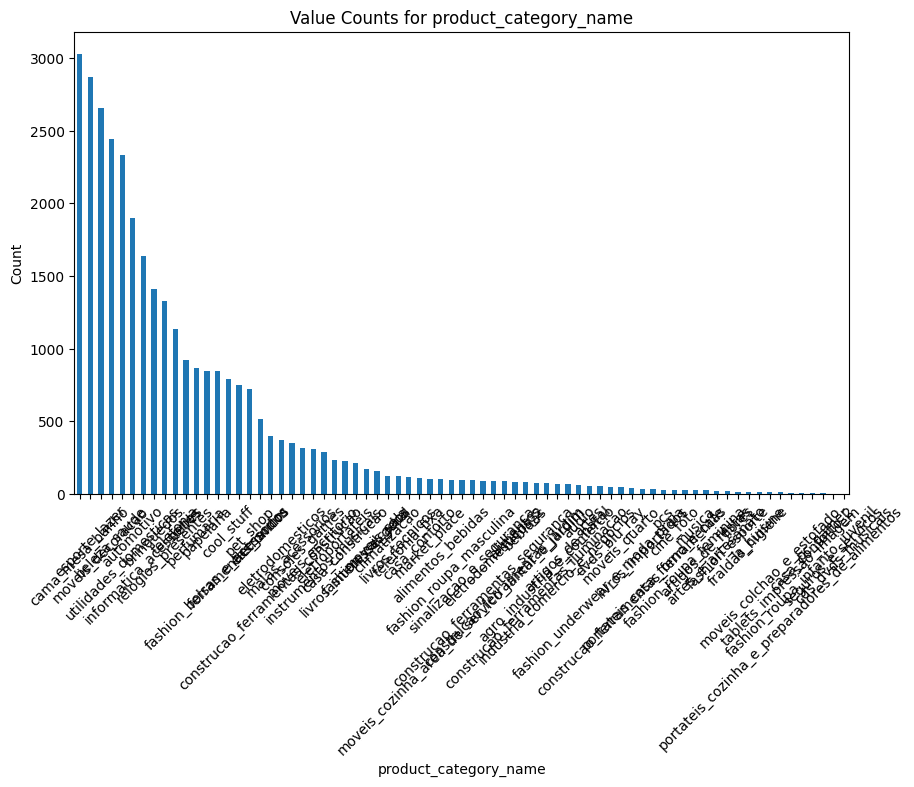

In [103]:
plot_value_counts(products,'product_category_name')

cleaning the data

In [104]:
products.duplicated().sum()

np.int64(0)

In [107]:
assert products.duplicated().sum() == 0

no duplicate rows were found

In [105]:
remove_white_spaces(products)

In [106]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [130]:
export_df_to_parquet(products,'products.parquet')

## loading sellers dataset

In [108]:
try:
  sellers=pd.read_csv(f"{DATA_PATH}/olist_sellers_dataset.csv")
except Exception as e:
  print(f"Error loading the dataset: {e}")


In [109]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [110]:
sellers.shape

(3095, 4)

In [111]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [112]:
sellers.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [113]:
sellers.describe(include="object")

,seller_id,seller_city,seller_state
count,3095,3095,3095
unique,3095,611,23
top,9e25199f6ef7e7c347120ff175652c3b,sao paulo,SP
freq,1,694,1849


In [113]:
value_counts_for_categorical_columns(sellers,['seller_id'])


COLUMN: SELLER_CITY
Total Records: 3,095
Unique Values: 611
Missing Values: 0 (0.00%)

                                          Count  Percentage  Cumulative %
seller_city                                                              
sao paulo                                   694   22.423263     22.423263
curitiba                                    127    4.103393     26.526656
rio de janeiro                               96    3.101777     29.628433
belo horizonte                               68    2.197092     31.825525
ribeirao preto                               52    1.680129     33.505654
guarulhos                                    50    1.615509     35.121163
ibitinga                                     49    1.583199     36.704362
santo andre                                  45    1.453958     38.158320
campinas                                     41    1.324717     39.483037
maringa                                      40    1.292407     40.775444
sao jose do rio preto   

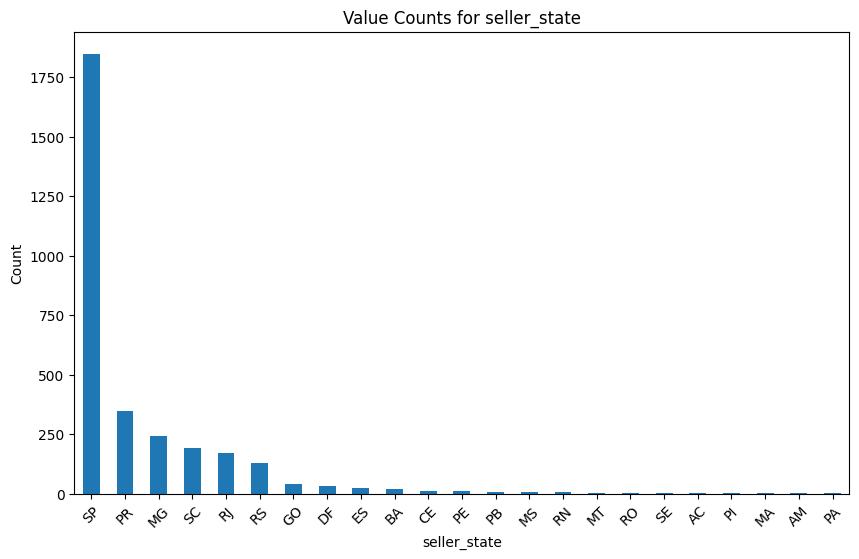

In [114]:
plot_value_counts(sellers,'seller_state')

## Data Cleaning

In [115]:
sellers.duplicated().sum()

np.int64(0)

no duplicate rows were found

In [116]:
remove_white_spaces(sellers)

In [117]:
padding_zip_codes(sellers,['seller_zip_code_prefix'])

In [118]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [119]:
export_df_to_parquet(sellers,'sellers.parquet')

## loading Product Category name transalation

In [120]:
try:
  product_category_name_translation=pd.read_csv(f"{DATA_PATH}/product_category_name_translation.csv")
except Exception as e:
  print(f"Error loading the dataset: {e}")


In [121]:
product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [119]:
product_category_name_translation.shape

(71, 2)

In [120]:
product_category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


### Cleaning the dataset

In [121]:
product_category_name_translation.duplicated().sum()

np.int64(0)

In [122]:
remove_white_spaces(product_category_name_translation)

In [132]:
export_df_to_parquet(product_category_name_translation,'product_category_name_translation.parquet')

### combining all cleaned df into an excel sheet

In [133]:
with pd.ExcelWriter('olist.xlsx') as writer:
    customers.to_excel(writer, sheet_name='customers', index=False)
    geolocation.to_excel(writer, sheet_name='geolocation', index=False)
    order_items.to_excel(writer, sheet_name='order_items', index=False)
    order_payments.to_excel(writer, sheet_name='order_payments', index=False)
    order_reviews.to_excel(writer, sheet_name='order_reviews', index=False)
    orders.to_excel(writer, sheet_name='orders', index=False)
    products.to_excel(writer, sheet_name='products', index=False)
    sellers.to_excel(writer, sheet_name='sellers', index=False)
    product_category_name_translation.to_excel(writer, sheet_name='product_category_name_translation', index=False)

/usr/local/lib/python3.12/dist-packages/openpyxl/workbook/child.py:99: UserWarning: Title is more than 31 characters. Some applications may not be able to read the file
  warnings.warn("Title is more than 31 characters. Some applications may not be able to read the file")
